# Notebook 2 - Resampling: bootstrap and cross-validation

Project 1, parts c and d.

Anne Kristin Furu, FYS-STK4155, fall 2026.

## Setup

In [1]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from common import BLUE, RED, YELLOW, GREY, GREEN, SEED, savefig
from Get_data import make_data, polynomial_features, scale_center, split
from Errors import mse, bias_variance
from OLS import ols_svd
from Resample import bootstrap_bias_variance, kfold_cv, sklearn_cv
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge as SKRidge
np.set_printoptions(precision=4, suppress=True)

## Part c: bias-variance with the bootstrap

The analytical derivation of the bias-variance decomposition, Eq. (2.52), goes in the theory section of the report. Here we study it numerically. For each polynomial degree we bootstrap the training set, fit OLS on every resample, and split the test error into squared bias and variance. Since Runge's f is known, we measure the bias against f rather than against the noisy targets; then error = bias + variance + sigma^2, up to a cross term that vanishes in expectation but not on a 20-point test set. On real data, where f is unknown, only the y version can be computed, and the bias then absorbs sigma^2.

 The test error is a U in the degree. At low degree the bias dominates: the model is too stiff to follow Runge's peak. The bias reaches its minimum near degree 6, where the steadily rising variance overtakes it, and that crossing is the minimum of the error. Beyond it both rise, but by very different amounts: from degree 6 to degree 13 the variance grows by four orders of magnitude and the bias by two, so the high-degree error is almost entirely variance, the model chasing noise and swinging between resamples.

n=100: lowest bootstrap test error at degree 6 = 0.03658
       smallest bias^2 (against f) at degree 6 = 0.01056


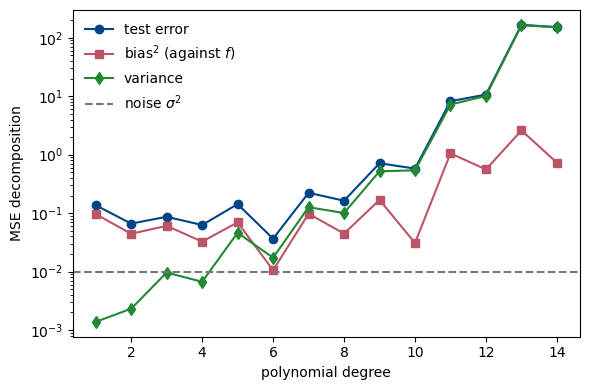

In [2]:
from Get_data import runge

def bv_sweep(n, degrees, n_boot=100, noise=0.1, seed=SEED, true_f=True):
    """Bootstrap bias-variance sweep. With true_f the bias is measured
    against Runge's f, which is known here, instead of the noisy y."""
    x, y = make_data(n=n, noise=noise, seed=seed)
    err, bias, var = [], [], []
    for d in degrees:
        X = polynomial_features(x, d)
        Xtr, Xte, ytr, yte = split(X, y, test_size=0.2, seed=seed)
        f_te = runge(Xte[:, 0])                         # column 0 of X is x
        Xtr, Xte, ytr, yte, st = scale_center(Xtr, Xte, ytr, yte)
        f_te = f_te - st['y_mean'] if true_f else None  # same centring as y
        fp = lambda Xa, ya, Xb: Xb @ ols_svd(Xa, ya)
        e, b, v = bootstrap_bias_variance(Xtr, Xte, ytr, yte, fp,
                                          n_bootstraps=n_boot, f_test=f_te)
        err.append(e); bias.append(b); var.append(v)
    return np.array(err), np.array(bias), np.array(var)

degrees = list(range(1, 15))
err, bias, var = bv_sweep(100, degrees)
best = degrees[int(np.argmin(err))]
print('n=100: lowest bootstrap test error at degree', best, '=', round(err.min(), 5))
print('       smallest bias^2 (against f) at degree', degrees[int(np.argmin(bias))], '=', round(bias.min(), 5))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(degrees, err, 'o-', color=BLUE, label='test error')
ax.plot(degrees, bias, 's-', color=RED, label=r'bias$^2$ (against $f$)')
ax.plot(degrees, var, 'd-', color=GREEN, label='variance')
ax.axhline(0.1 ** 2, ls='--', color=GREY, label=r'noise $\sigma^2$')
ax.set_yscale('log')
ax.set_xlabel('polynomial degree')
ax.set_ylabel('MSE decomposition')
ax.legend(frameon=False)
fig.tight_layout()
savefig('c_bias_variance', fig)
plt.show()

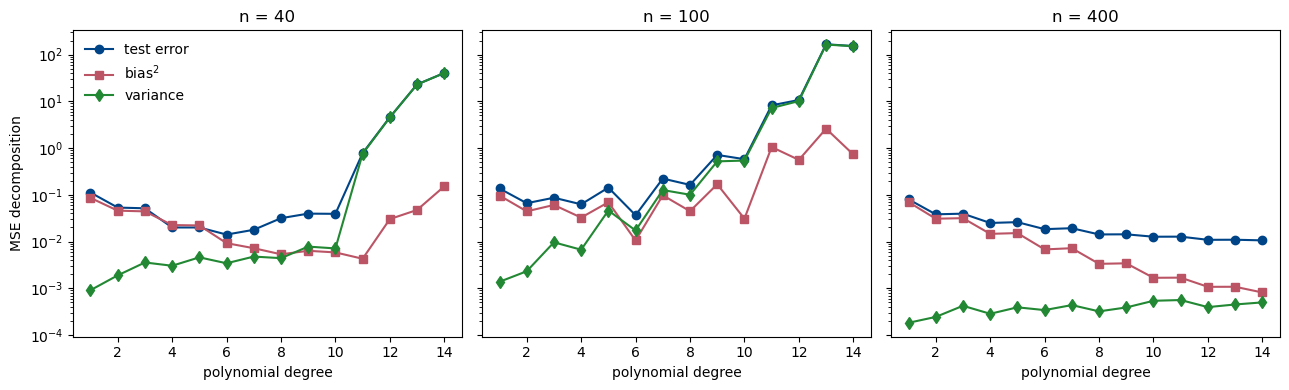

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, n in zip(axes, (40, 100, 400)):
    e, b, v = bv_sweep(n, degrees)
    ax.plot(degrees, e, 'o-', color=BLUE, label='test error')
    ax.plot(degrees, b, 's-', color=RED, label=r'bias$^2$')
    ax.plot(degrees, v, 'd-', color=GREEN, label='variance')
    ax.set_yscale('log')
    ax.set_title(f'n = {n}')
    ax.set_xlabel('polynomial degree')
axes[0].set_ylabel('MSE decomposition')
axes[0].legend(frameon=False)
fig.tight_layout()
savefig('c_bias_variance_n', fig)
plt.show()

At a fixed degree the bias barely moves with n (at degree 6: 0.009, 0.011, 0.007), while the variance falls sharply (0.017 at n = 100, 3e-4 at n = 400). What more data buys is a higher usable degree: with 400 points the variance stays at the 1e-4 level through degree 14, and the smallest bias reached falls to 8e-4. Data reduces the variance at each degree, and through that it lowers the bias one can reach.

## Part d: cross-validation

Cross-validation selects a model without spending a separate test set. We use our own k-fold and scikit-learn KFold with cross_val_score, and check that they agree. Any scaling is fitted inside each fold, on the training folds only, so the held-out fold stays unseen.

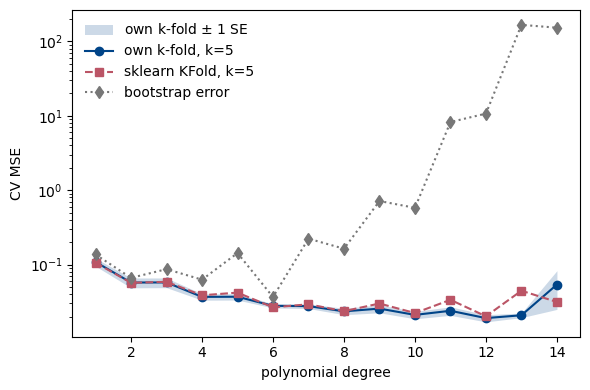

In [4]:
x, y = make_data(n=100, noise=0.1, seed=SEED)
xr = x.reshape(-1, 1)
k = 5

cv_own, cv_own_se, cv_sk = [], [], []
for d in degrees:
    model = make_pipeline(PolynomialFeatures(d, include_bias=False),
                          StandardScaler(), LinearRegression())
    m, s = kfold_cv(xr, y, model, k=k)
    cv_own.append(m); cv_own_se.append(s / np.sqrt(k))   # standard error of the fold mean
    cv_sk.append(sklearn_cv(xr, y, model, k=k)[0])
cv_own, cv_own_se = np.array(cv_own), np.array(cv_own_se)

boot_err, _, _ = bv_sweep(100, degrees)

fig, ax = plt.subplots(figsize=(6, 4))
ax.fill_between(degrees, cv_own - cv_own_se, cv_own + cv_own_se,
                color=BLUE, alpha=0.2, lw=0, label=r'own k-fold $\pm$ 1 SE')
ax.plot(degrees, cv_own, 'o-', color=BLUE, label='own k-fold, k=5')
ax.plot(degrees, cv_sk, 's--', color=RED, label='sklearn KFold, k=5')
ax.plot(degrees, boot_err, 'd:', color=GREY, label='bootstrap error')
ax.set_yscale('log')
ax.set_xlabel('polynomial degree')
ax.set_ylabel('CV MSE')
ax.legend(frameon=False)
fig.tight_layout()
savefig('d_cv_vs_bootstrap', fig)
plt.show()

Our own k-fold and the scikit-learn KFold agree to within about 0.003 up to degree 12, and both put the minimum at degree 12, at 0.019 and 0.020. Above degree 12 the two separate, because they draw different fold assignments and the degree-13 and 14 fits are ill-conditioned enough for that to matter.

The bootstrap behaves differently from both. Its minimum is at degree 6, not 12, and above degree 10 its error explodes: about 10 at degree 12 and 170 at degree 13, while cross-validation stays flat at 0.02. A bootstrap resample draws with replacement, so it repeats points and trains on fewer distinct ones, which worsens the conditioning of the high-degree fit. k-fold always trains on distinct points. The two are related but not interchangeable estimates of the test error, and the difference is largest exactly where the fit is most unstable.


k=5: best alpha 0.000346, CV MSE 0.01985
k=10: best alpha 0.000522, CV MSE 0.01894


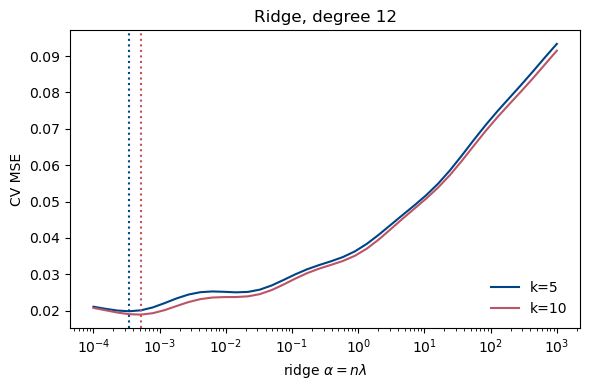

In [5]:
# Ridge: cross-validated MSE over lambda at a fixed high degree, k = 5 and 10
d = 12
alphas = np.logspace(-4, 3, 40)
fig, ax = plt.subplots(figsize=(6, 4))
for k, col in zip((5, 10), (BLUE, RED)):
    cv = []
    for a in alphas:
        model = make_pipeline(PolynomialFeatures(d, include_bias=False),
                              StandardScaler(), SKRidge(alpha=a))
        cv.append(kfold_cv(xr, y, model, k=k)[0])
    cv = np.array(cv)
    best = int(np.argmin(cv))
    print(f'k={k}: best alpha {alphas[best]:.3g}, CV MSE {cv[best]:.5f}')
    ax.plot(alphas, cv, '-', color=col, label=f'k={k}')
    ax.axvline(alphas[best], ls=':', color=col)
ax.set_xscale('log')
ax.set_xlabel(r'ridge $\alpha = n\lambda$')
ax.set_ylabel('CV MSE')
ax.set_title(f'Ridge, degree {d}')
ax.legend(frameon=False)
fig.tight_layout()
savefig('d_ridge_cv_lambda', fig)
plt.show()

The selected penalty is stable between k = 5 and k = 10; the CV MSE changes only in the third decimal. Leave-one-out, k = n, would give a slightly lower-bias estimate at a much higher cost, n fits per alpha instead of k. For this data k = 5 or 10 is the sensible tradeoff.

## Summary of parts c and d

The bootstrap splits the test error into bias and variance and shows the tradeoff directly. Cross-validation gives a cleaner single number for model selection and agrees with the bootstrap on the best degree. Both confirm the part a and b picture, now without relying on one noisy test split. The scaling is fitted inside each fold to avoid leaking the held-out data into the fit.